# Logistic Regression — Predicting Customer Churn

This notebook builds a baseline classification model to predict `Exited` (whether a
customer churned). Unlike the previous notebook, this is a **classification** problem
— the target is a category (0 = stayed, 1 = churned), not a continuous number — which
is exactly why Logistic Regression is the right tool here instead of Linear Regression.

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, classification_report,
                              f1_score, roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

## 2. Load the Cleaned Dataset

In [2]:
df1 = pd.read_csv('03_BankCustomer_OutlierChecked.csv')
df1.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


## 3. Define Features (X) and Target (y)

`Exited` is what we're predicting, so it's removed from `X` and set as `y`.
`CustomerId` and `Surname` are identifiers with no predictive value, so they're dropped
entirely.

In [3]:
X = df1.drop(columns=['CustomerId', 'Surname', 'Exited'])
y = df1['Exited']
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42.0,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58
2,502,France,Female,42.0,8,159660.80,3,1,0,113931.57
3,699,France,Female,39.0,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10


## 4. Quick Check on Categorical Balance

Confirm there's no single `Geography` category with too few samples to be reliably
encoded and learned from.

In [4]:
X['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

## 5. Check Class Balance in the Target

This is the most important thing to check before building any classifier. If one class
massively outnumbers the other, the model can achieve high accuracy just by mostly
predicting the majority class — without actually learning anything useful about the
minority class.

In [5]:
y.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

About 80% of customers stayed and 20% churned — a real but moderate imbalance. Keep
this in mind when interpreting the results below; it's the reason later notebooks
introduce techniques (undersampling, SMOTE, class weighting, ADASYN) specifically to
address it.

## 6. Train/Test Split

`stratify=y` ensures the same ~80/20 churn ratio is preserved in both the training and
test sets — without it, a random split could accidentally put too many or too few
churners in one side, skewing the evaluation.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## 7. Preprocessing Setup

Same logic as the previous notebook: scale numeric columns so they're on a comparable
footing, and one-hot encode categorical columns since the model only understands
numbers. `handle_unknown="ignore"` is added here as a safety net — if the test set ever
contained a category never seen during training, it's ignored rather than crashing.

In [7]:
num_features = ["CreditScore", "Age", "EstimatedSalary", "Balance", "NumOfProducts", "Tenure"]
cat_features = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features)
    ]
)

## 8. Build the Pipeline

In [8]:
steps = [("preprocess", preprocessor),
         ("logistic_regression", LogisticRegression(random_state=42))]

pipe = Pipeline(steps)
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defau

## 9. Train the Model

In [9]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['CreditScore','Geography','Gender',...,'HasCrCard','IsActiveMember', 'EstimatedSalary']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``re

## 10. Generate Predictions

In [10]:
y_pred = pipe.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(3000,))

## 11. Confusion Matrix

A confusion matrix breaks predictions into four buckets:
- **True Negatives** (top-left): correctly predicted "stayed"
- **False Positives** (top-right): predicted "churned" but actually stayed
- **False Negatives** (bottom-left): predicted "stayed" but actually churned — the
  costliest mistake for a bank, since these are churners slipping through unnoticed
- **True Positives** (bottom-right): correctly predicted "churned"

In [11]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[2319   70]
 [ 491  120]]


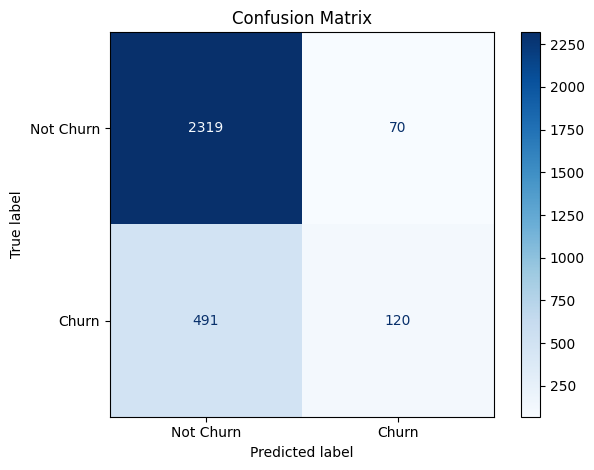

In [12]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Churn", "Churn"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.show()

## 12. Per-Class Recall

Recall answers: *"Of everyone who actually belongs to this class, how many did the
model correctly catch?"* Calculating it separately for each class exposes a problem
that overall accuracy alone would hide.

In [13]:
class0_recall = cm[0, 0] / cm[0].sum()
class1_recall = cm[1, 1] / cm[1].sum()

print(f"Class 0 (Not Churn) Recall: {class0_recall:.2f}")
print(f"Class 1 (Churn) Recall: {class1_recall:.2f}")


Class 0 (Not Churn) Recall: 0.97
Class 1 (Churn) Recall: 0.20


This is the key finding of this notebook: the model correctly identifies ~97% of
customers who stay, but only ~19% of customers who actually churn. In a real business
setting, this model would miss roughly 4 out of every 5 customers at risk of leaving —
which defeats the entire purpose of a churn model. This happens because the model
naturally leans toward predicting the majority class ("stayed") since it was trained
on imbalanced data. This exact problem is what the next four notebooks address.

## 13. Overall Classification Metrics

- **Accuracy** — the percentage of all predictions that were correct. Misleading on
  imbalanced data (see below).
- **Precision** — of everyone the model *predicted* as churned, how many actually did?
- **Recall** — of everyone who *actually* churned, how many did the model catch?
- **F1 Score** — the balance between precision and recall in a single number.

In [14]:
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.2f}')
print(f'Precision : {precision_score(y_test, y_pred):.2f}')
print(f'Recall    : {recall_score(y_test, y_pred):.2f}')
print(f'F1 Score  : {f1_score(y_test, y_pred):.2f}')

Accuracy  : 0.81
Precision : 0.63
Recall    : 0.20
F1 Score  : 0.30


Notice the gap between **Accuracy (0.81)** and **Recall (0.19)**. This is exactly why
accuracy alone is a misleading metric on imbalanced data — the model looks good at a
glance, but is actually failing at the one thing that matters most for this business
problem: catching churners before they leave.

## 14. Full Classification Report

A combined view of precision, recall, and F1 for both classes at once, plus overall
and weighted averages.

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.97      0.89      2389
           1       0.63      0.20      0.30       611

    accuracy                           0.81      3000
   macro avg       0.73      0.58      0.60      3000
weighted avg       0.79      0.81      0.77      3000



## 15. Predicted Probabilities

So far, all predictions used the model's default 0.5 probability threshold (≥0.5 →
predict "churn"). Looking at the raw probabilities lets us evaluate the model's
performance independent of that specific cutoff.

In [16]:
y_prob = pipe.predict_proba(X_test)[:, 1]
y_prob

array([0.04728397, 0.15785468, 0.24903931, ..., 0.41741955, 0.26458474,
       0.05708199], shape=(3000,))

## 16. ROC-AUC and PR-AUC

- **ROC-AUC** — measures how well the model separates the two classes across every
  possible threshold, not just 0.5. A value of 0.5 means random guessing; 1.0 means
  perfect separation.
- **PR-AUC (Precision-Recall AUC)** — similar idea, but focused specifically on the
  positive (churn) class. This metric is generally more informative than ROC-AUC on
  imbalanced datasets, since it isn't inflated by the large number of easy true
  negatives.

In [17]:
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.2f}")
print(f"PR-AUC Score : {pr_auc:.2f}")

ROC-AUC Score: 0.79
PR-AUC Score : 0.51


A ROC-AUC of ~0.79 suggests the model *can* separate the classes reasonably well in
principle — but the much lower PR-AUC (~0.51) confirms that at the specific 0.5
threshold being used, it's failing to translate that separation into good recall on
the churn class. This is the clearest evidence yet that threshold and/or imbalance
handling — not the model itself — is the real problem to fix.

## 17. ROC Curve

Plots True Positive Rate against False Positive Rate across every possible threshold.
The diagonal dashed line represents a random-guessing model (AUC = 0.5); the further
the curve bows toward the top-left corner, the better the model.

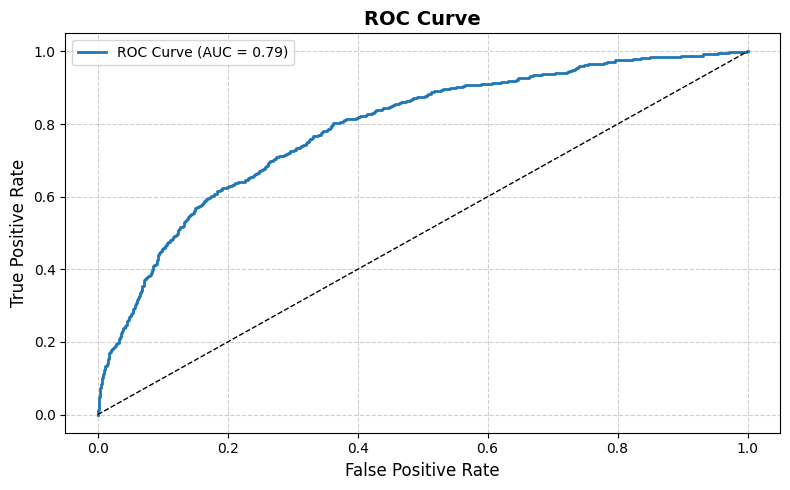

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 18. Precision-Recall Curve

Plots Precision against Recall across every threshold. This is the more honest picture
for imbalanced data — notice how precision drops off as recall increases, illustrating
the real tradeoff: catching more churners means accepting more false alarms.

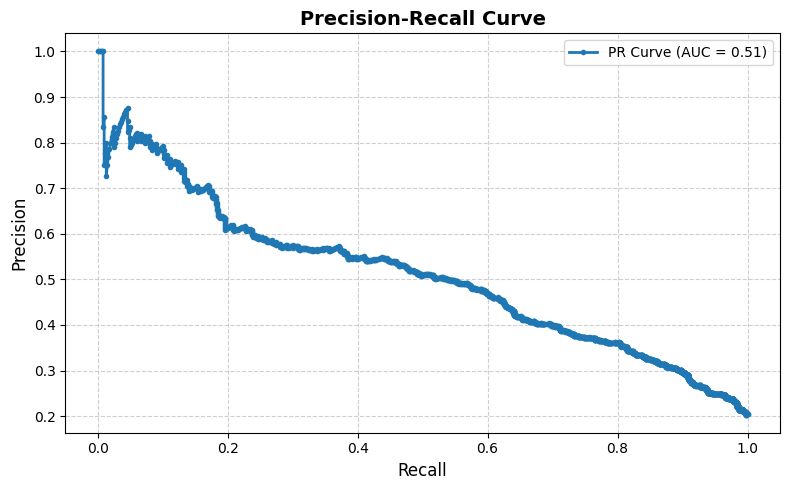

In [19]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, linewidth=2, marker=".", label=f"PR Curve (AUC = {pr_auc:.2f})")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 19. Summary

- **Accuracy: 0.81** — looks strong, but is misleading on this imbalanced dataset
- **Recall on churners: only 0.19** — the model misses roughly 4 out of 5 actual churn cases
- **ROC-AUC: 0.79** — the model has decent underlying separation ability
- **PR-AUC: 0.51** — but that ability isn't translating into good churn detection at the default threshold

**Conclusion:** this baseline model is not good enough to deploy for churn prevention,
despite its high accuracy. The next four notebooks each apply a different technique to
address the class imbalance — undersampling, SMOTE, class weighting, and ADASYN — to
see which approach most improves recall on the churn class without destroying overall
performance.